In [ ]:
from itertools import cycle
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, DistributedSampler
from torchvision import datasets, transforms
from model import LeNet5


tran = transforms.Compose((transforms.ToTensor(), transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))))
full_train_dataset = datasets.CIFAR100(root='./data', train=True, download=True, transform=tran)

train_size = int(0.8 * len(full_train_dataset))  # 80% for training
val_size = len(full_train_dataset) - train_size  # 20% for validation

train_dataset, val_dataset = random_split(full_train_dataset, (train_size, val_size))

# dloader = DataLoader(train_dataset, 10000, shuffle=True, pin_memory=True)
# print(len(dloader))


In [ ]:
from distributed import distributed_learning

model = distributed_learning(train_dataset, 5, 2, 2, 500, torch.optim.Adam, {"lr": 0.01})

In [ ]:
import experiments_config
from functools import partial
import os
import time
import ray
import torch
from torchvision import datasets, transforms
from torch.utils.data import random_split
from ray import tune
from ray.tune import CLIReporter
# from ray.tune.search.variant_generator import BasicVariantGenerator

from distributed import distributed_learning
from hyperparameter import custom_trial_name, tune_distributed_learning
from model import evaluate_model, load_data
import experiments_config


search_space = experiments_config.play_araound

experment_folder = os.path.join(os.path.abspath("ray_results"), f"play_arr")

train_dataset, val_dataset = load_data()

ray.init()
train_data_obj_ref = ray.put((train_dataset, val_dataset))

reporter = CLIReporter(metric_columns=["val_loss", "val_acc"])

print("Cuda available:", torch.cuda.is_available())

analysis = tune.run(
    partial(tune_distributed_learning, train_data_obj_ref=train_data_obj_ref),
    config=search_space,
    num_samples=2,
    progress_reporter=reporter,
    storage_path=experment_folder,
    max_concurrent_trials=1,
    trial_name_creator=custom_trial_name,
    trial_dirname_creator=lambda t: f"trial_{t.trial_id}",
    metric="val_acc",
    mode="max"
)
print("Best hyperparameters found: ", analysis.best_config)
print("Best validation accuracy: ", analysis.best_result)

analysis.results_df.to_csv(os.path.join(experment_folder, "playy_arrsas_ress.csv"))


In [2]:
import json
import pandas as pd
import os
def gen_dataframe(s):
    l = []
    for folder in os.listdir(s):
        folder = os.path.join(s, folder)
        if os.path.isdir(folder):
            with open(os.path.join(folder, "result.json"), "r") as f:
                res = json.load(f)

            res.pop("config")
            with open(os.path.join(folder, "params.json"), "r") as f:
                params = json.load(f)
            
            for k, v in params.items():
                res[f"config/{k}"] = v

            l.append(res)
    df = pd.DataFrame(l)
    # df.to_pickle(os.path.join(s, "analysis_results.pkl"))
    return df
    

df = gen_dataframe("ray_results\\mini_batch_adamw_correct_scheduler_2025-01-04_22-26-31")

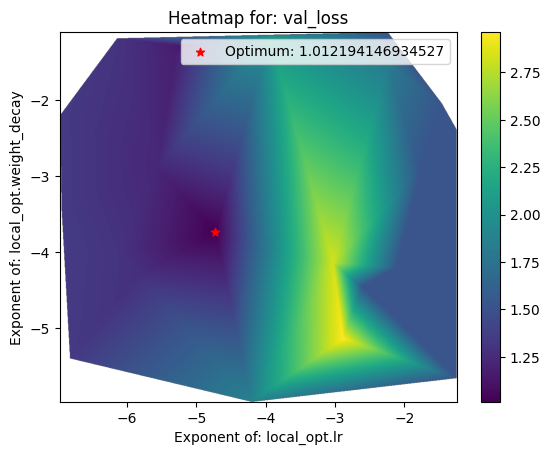

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import LinearNDInterpolator

def hyper_params_heatmap(results, param_1_name, param_2_name, log_scale_1=True, 
                         log_scale_2=True, metric="val_acc", mode="max", log_metric=False):
    x = results[f"config/{param_1_name}"]
    y = results[f"config/{param_2_name}"]

    if log_scale_1:
        x = np.log10(x)
        param_1_name = "Exponent of: " + param_1_name
    if log_scale_2:
        y = np.log10(y)
        param_2_name = "Exponent of: " + param_2_name

    val = results[metric] 

    if log_metric:
        val = np.log(val)

    inter = LinearNDInterpolator((x, y), val)

    x_int = np.linspace(x.min(), x.max(), 1000)
    y_int = np.linspace(y.min(), y.max(), 1000)
    mesh = np.meshgrid(x_int, y_int)
    inter_val = inter(mesh)

    plt.imshow(inter_val, extent=[x_int[0], x_int[-1], y_int[0], y_int[-1]], origin="lower", aspect="auto")
    plt.colorbar()

    opt_ind = np.argmax(val) if mode == "max" else np.argmin(val)
    plt.scatter(x[opt_ind], y[opt_ind], c="r", marker="*", label=f"Optimum: {val[opt_ind]}")

    plt.xlabel(param_1_name)
    plt.ylabel(param_2_name)
    plt.title(f"Heatmap for: {metric}")
    plt.legend()



hyper_params_heatmap(df, "local_opt.lr", "local_opt.weight_decay", True, True, "val_loss", "min", True)



In [5]:
df.filter(["config/local_opt.lr", "config/local_opt.weight_decay", "val_loss"]).sort_values("val_loss")#.sort_values("val_acc", ascending=False)

,config/local_opt.lr,config/local_opt.weight_decay,val_loss
9,1.881256e-05,0.000186,2.751632
4,5.867677e-06,0.052447,3.130336
22,4.973151e-06,0.041345,3.242989
12,2.730091e-06,0.001311,3.408460
21,1.504057e-06,0.000052,3.599563
18,7.848196e-07,0.000099,3.671155
15,7.124641e-07,0.066276,3.689577
0,2.744500e-07,0.000100,3.793155
10,1.493556e-07,0.000004,3.818248
16,1.074798e-07,0.006446,3.834655


In [ ]:
criterion = nn.CrossEntropyLoss()


In [ ]:
import seaborn as sns


sns.heatmap()

In [ ]:
import matplotlib.pyplot as plt

def plot_metric(metric, **kwargs):
    plt.plot(range(len(metric)), metric, **kwargs)
    plt.xlabel("Epochs")
    plt.grid(True)


plot_metric(train_loss, marker="x")
plot_metric(eval_loss)
plt.ylabel("Loss")

In [6]:
[2**i for i in range(9, 13)]

[512, 1024, 2048, 4096]

In [15]:
from torch.optim import Adam, SGD
from torch.optim.lr_scheduler import CosineAnnealingLR, LRScheduler, PolynomialLR
from model import LeNet5
CosineAnnealingLR(Adam(LeNet5().parameters()), total_iters=10)


TypeError: CosineAnnealingLR.__init__() got an unexpected keyword argument 'total_iters'